In [1]:
pip install pandas geopandas folium branca

   ---------------------------------------- 0.0/23.6 MB ? eta -:--:--
   --------- ------------------------------ 5.8/23.6 MB 27.8 MB/s eta 0:00:01
   -------------------- ------------------- 11.8/23.6 MB 28.6 MB/s eta 0:00:01
   ------------------------------ --------- 18.1/23.6 MB 28.9 MB/s eta 0:00:01
   ---------------------------------------  23.3/23.6 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------  23.3/23.6 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------  23.3/23.6 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------  23.3/23.6 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------  23.3/23.6 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------  23.3/23.6 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------- 23.6/23.6 MB 11.4 MB/s  0:00:02
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ---------------------------------------  6.3/6.4 MB 31.6 MB/s eta 0:00:0

In [5]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------------- -------------- 5.2/8.3 MB 26.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 22.7 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 19.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.2 MB 8.1 MB/s eta 0:00:01
   ---------------------------------- ----- 6.3/7.2 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 14.5 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [

In [7]:
pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ----- ---------------------------------- 5.0/37.3 MB 28.8 MB/s eta 0:00:02
   ----------- ---------------------------- 10.5/37.3 MB 26.0 MB/s eta 0:00:02
   ---------------- ----------------------- 14.9/37.3 MB 24.5 MB/s eta 0:00:01
   --------------------- ------------------ 20.4/37.3 MB 24.8 MB/s eta 0:00:01
   --------------------------- ------------ 25.7/37.3 MB 25.0 MB/s eta 0:00:01
   --------------------------------- ------ 31.5/37.3 MB 25.0 MB/s eta 0:00:01
   ---------------------------------------  36.7/37.3 MB 25.2 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 22.2 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

In [23]:
clean_india_fires = pd.read_csv("C:/Users/nekos/geo876-final-project/geo876-final-project/data/processed/clean_india_fires.csv")

clean_india_fires.head()

,latitude,longitude,frp,daynight,datetime
0,17.90913,82.63764,4.76,D,2026-05-14 07:12:00
1,17.90961,82.63640,4.82,D,2026-05-14 07:12:00
2,18.20374,77.79069,12.03,D,2026-05-14 07:12:00
3,18.20650,77.79298,8.55,D,2026-05-14 07:12:00
4,18.47787,79.45326,7.81,D,2026-05-14 07:12:00


In [24]:
clean_india_fires["frp_norm"] = clean_india_fires["frp"] / clean_india_fires["frp"].max()
HeatMapData = clean_india_fires[["latitude", "longitude", "frp_norm"]].values.tolist()

In [25]:
clean_india_fires["datetime"] = pd.to_datetime(clean_india_fires["datetime"]) 
clean_india_fires["date"] = clean_india_fires["datetime"].dt.date

In [43]:
#Map of the fire points and the kernel density
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)
india_boundary = world[world["ADMIN"] == "India"]

In [44]:
india_fires_map = LinearSegmentedColormap.from_list(
    "fire_scale",
    ["#ffffff", "#fff7bc", "#fec44f", "#f03b20", "#bd0026"]
)

In [58]:
def plot_fire_points(clean_india_fires, target_date):

    d = clean_india_fires[clean_india_fires["date"] == target_date].copy()

    if len(d) < 5:
        print(f"Skipping {target_date} (not enough data)")
        return

    x = d["longitude"].values
    y = d["latitude"].values
    w = d["frp_norm"].values

    fig, ax = plt.subplots(figsize=(9, 8))

    india_boundary.plot(
        ax=ax,
        color="black",
        edgecolor="black",
        linewidth=1
    )

    sc = ax.scatter(
        x, y,
        c=w,
        cmap=india_fires_map,
        s=15,
        edgecolor="none"
    )

    plt.title(f"Fire Points in India on {target_date}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    plt.colorbar(sc, ax=ax, label="FRP (normalised)")

    save_path = f"C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fire_points_{target_date}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

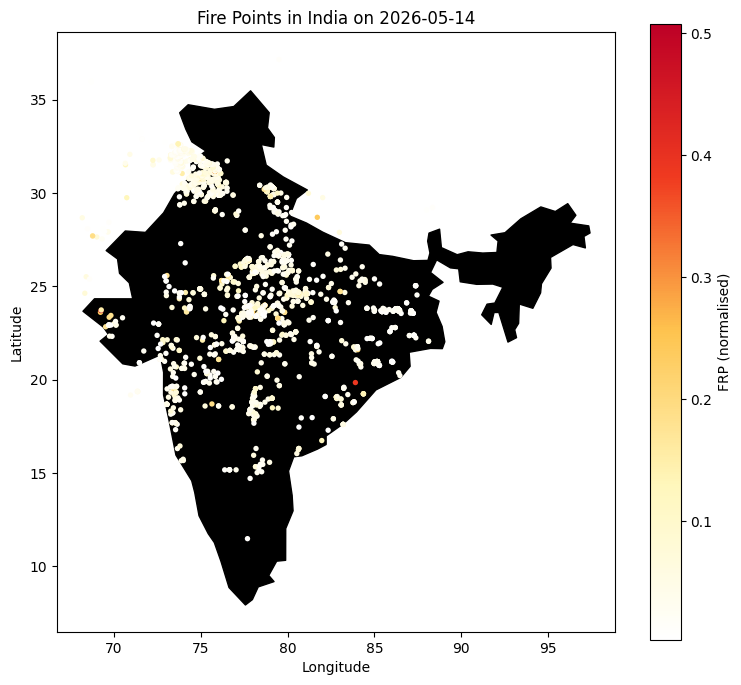

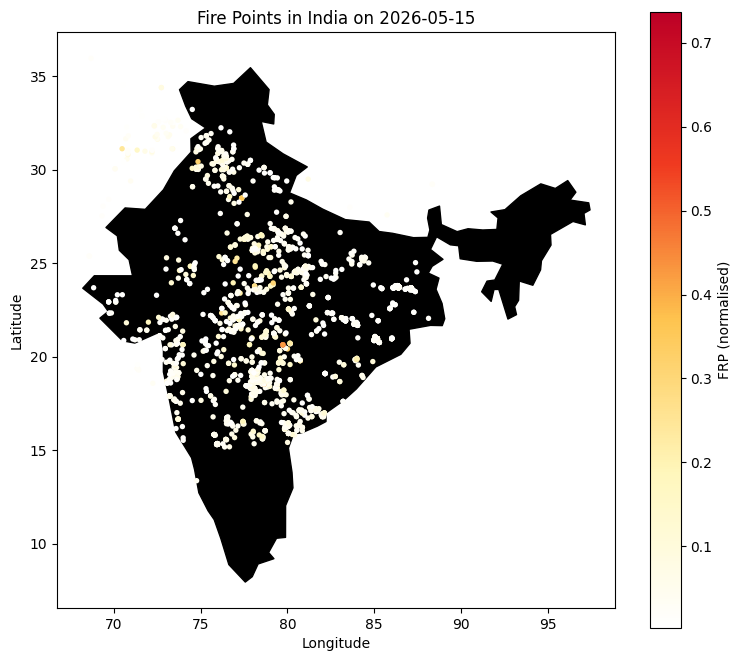

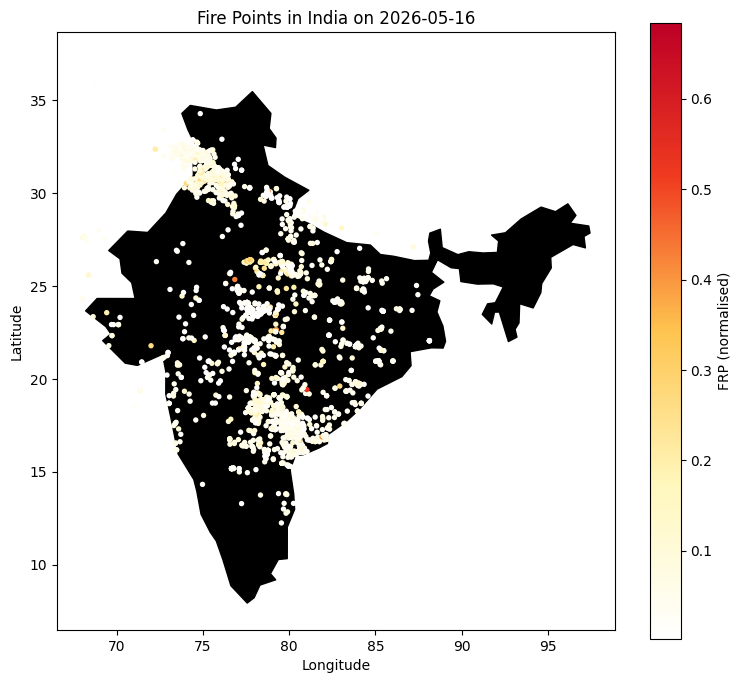

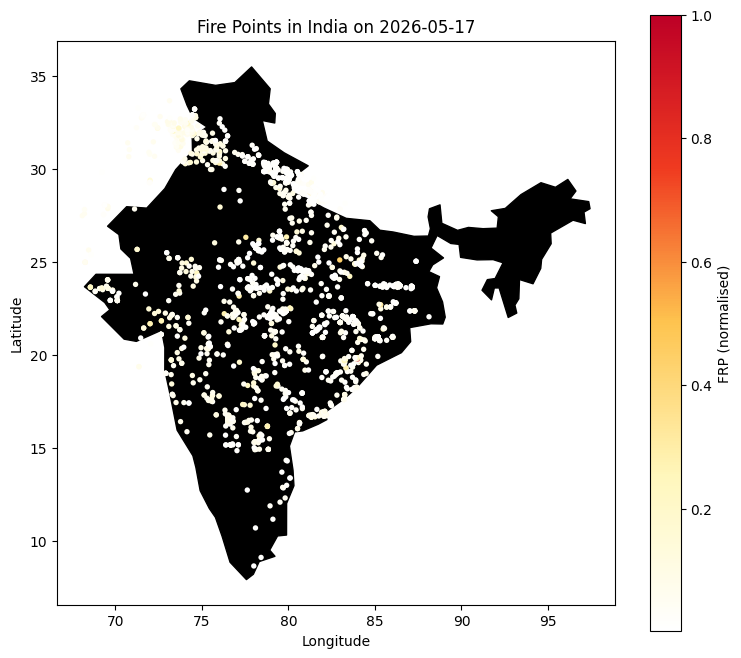

In [59]:
for d in clean_india_fires["date"].unique():
    plot_fire_points(clean_india_fires, d)

In [64]:
def plot_kde_day(clean_india_fires, target_date):

    d = clean_india_fires[clean_india_fires["date"] == target_date].copy()

    # safety check
    if len(d) < 5:
        print(f"Skipping {target_date} (not enough data)")
        return

    x = d["longitude"].values
    y = d["latitude"].values
    w = d["frp_norm"].values

    # avoid crash if all points identical range
    if x.min() == x.max() or y.min() == y.max():
        print(f"Skipping {target_date} (zero spatial variation)")
        return

    # grid
    xi, yi = np.mgrid[
        x.min():x.max():200j,
        y.min():y.max():200j
    ]

    coords = np.vstack([x, y])
    grid_coords = np.vstack([xi.ravel(), yi.ravel()])

    # weighted KDE
    kde = gaussian_kde(coords, weights=w, bw_method=0.2)
    zi = kde(grid_coords).reshape(xi.shape)

    # plot
    fig, ax = plt.subplots(figsize=(9, 8))
    india_boundary.plot(ax=ax, color="none", edgecolor="black", linewidth=1)
    plt.title(f"Most Severe Fires in India on {target_date}")

    plt.imshow(
        np.rot90(zi),
        cmap=india_fires_map,
        extent=[x.min(), x.max(), y.min(), y.max()],
        aspect="auto"
    )

    plt.colorbar(label="FRP (normalised)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    save_path = f"C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fires_{target_date}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    print("Saved:", save_path)

    # 🔥 SHOW MAP IN JUPYTER
    plt.show()

Saved: C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fires_2026-05-14.png


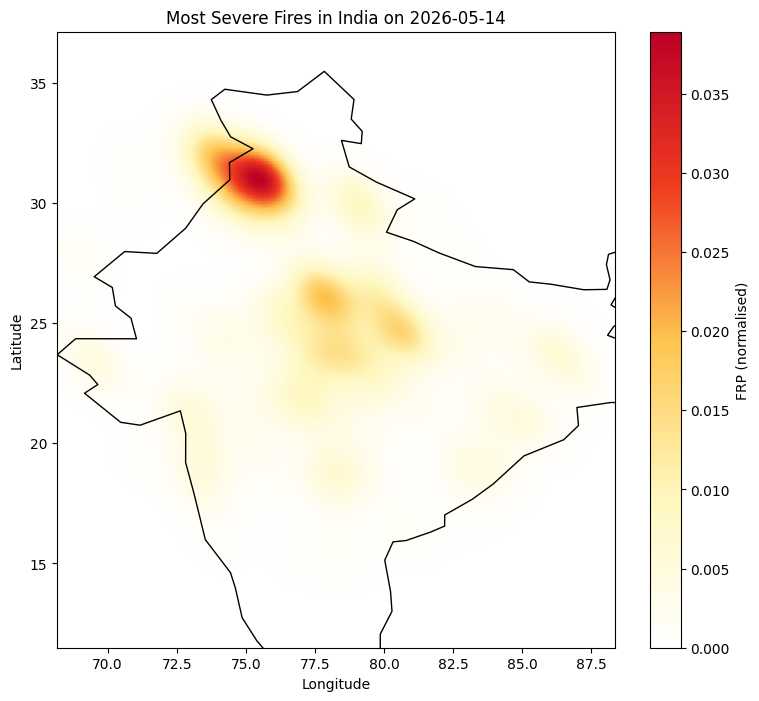

Saved: C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fires_2026-05-15.png


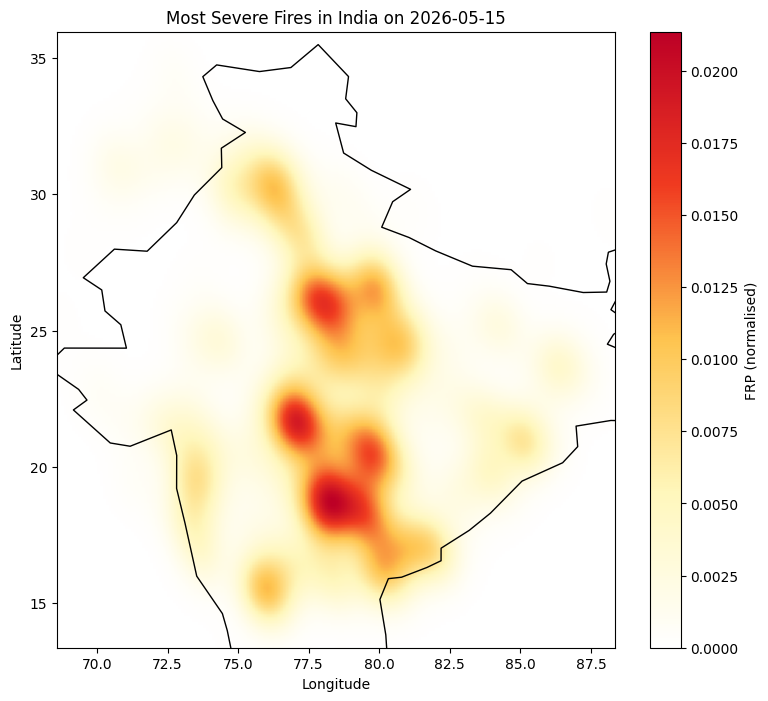

Saved: C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fires_2026-05-16.png


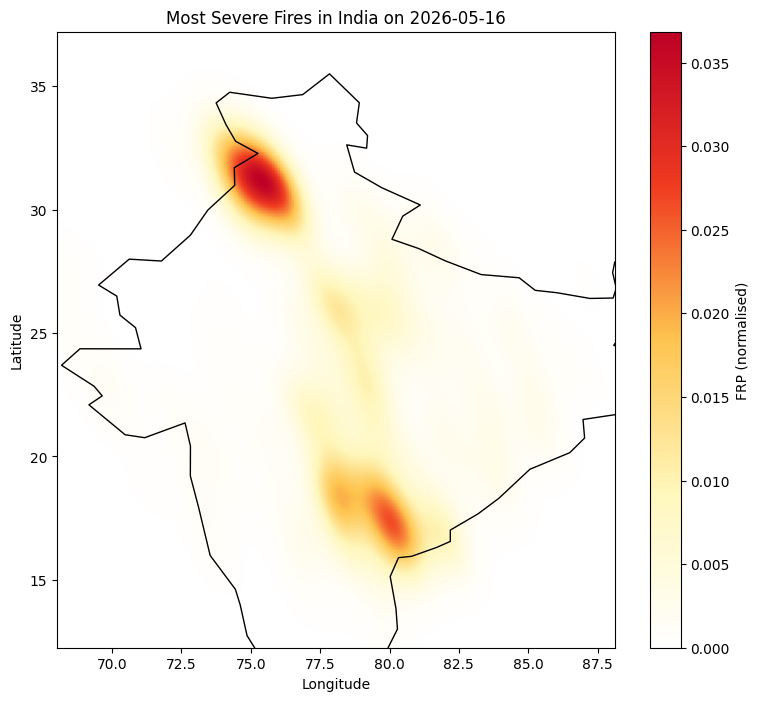

Saved: C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_fires_2026-05-17.png


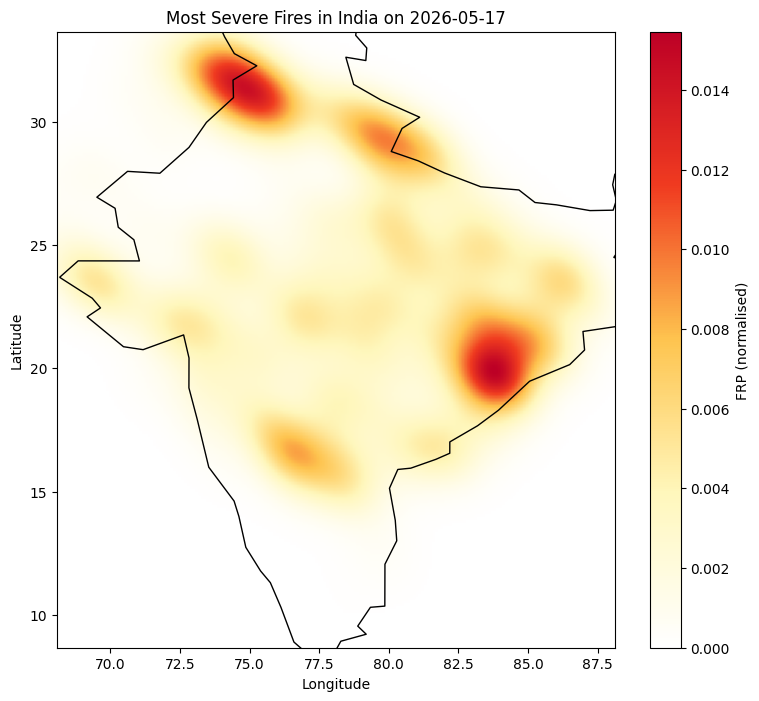

In [65]:
for d in clean_india_fires["date"].unique():
    plot_kde_day(clean_india_fires, d)